# Introduction to Realitymapping

Welcome to the introduction to the Reality Mapping series. This guide provides an overview of key reality mapping concepts and workflows, explains how to set up the required environment, and points you to relevant resources to help you get started with reality mapping.

Photogrammetric imagery acquired from drones, aerial platforms, and satellites will inevitably be affected by geometric distortions caused by sensor tilt, platform motion, terrain relief, and Earth curvature, making raw images unsuitable for accurate mapping and measurement. An example of distortion caused by camera tilt or terrain displacement is shown in the figure below.

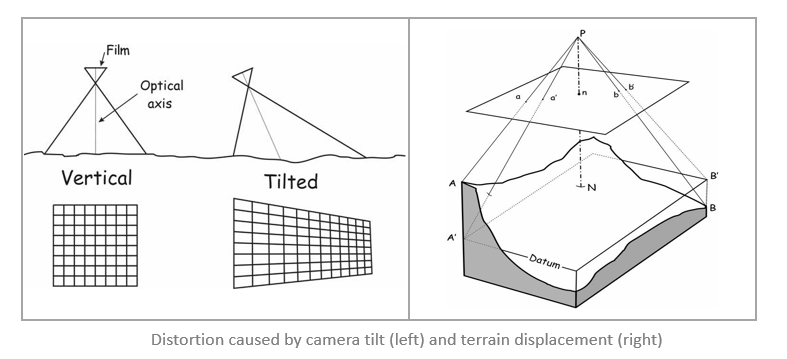

These geometric distortions must be removed using sensor models, image geometry, and elevation information to produce map‑accurate imagery. Once images are properly rectified and spatially aligned, there is often a need to derive high‑fidelity 2D and 3D products that accurately represent the real world. These products include true orthos for precise planar representation, as well as elevation models, dense point clouds, and textured meshes for three‑dimensional analysis and visualization. Reality mapping brings these steps together as a comprehensive workflow, combining rigorous image adjustment with the generation of high‑quality 2D and 3D products, enabling accurate measurement, realistic visualization, and reliable use of imagery for mapping, analysis, and decision‑making.

## Getting Started

Reality mapping capability through ArcGIS API for Python is currently available with ArcGIS Enterprise federated with a [Reality Server](https://doc.esri.com/en/arcgis-reality-server/latest/introduction/what-is-reality-server.html) license. ArcGIS Reality Server provides distributed computing and storage systems that power reality mapping capabilities for large collections of drones, digital aerial, and satellite images. See the [configuration instruction](https://doc.esri.com/en/arcgis-reality-server/latest/deploy/configure-arcgis-reality.html) for setup details. ArcGIS Online does not yet support reality mapping.


Once your environment is configured, import the required class and module:

- [GIS](/python/latest/api-reference/arcgis.gis.toc.html#gis) class: Represents the organizational deployment and accesses classes to manage content, users, and groups

-  [arcgis.raster.realitymapping](/python/latest/api-reference/arcgis.raster.realitymapping.html) submodule provides the functionality to automate reality mapping tasks in the server environment. The reality mapping module is available with ArcGIS API for Python (version >= 2.4.2)

In [1]:
from arcgis.gis import GIS
from arcgis.raster import realitymapping

Establish a connection to your ArcGIS Enterprise portal

In [ ]:
gis = GIS(url = "https://yourportal.domain.com/portal/",
            username = "your username",
            password = "your password")

To verify if your GIS has reality mapping capability, use the [realitymapping.is_supported(gis)](/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster.realitymapping.is_supported) method. This function returns True if the GIS supports reality mapping.

In [3]:
realitymapping.is_supported(gis)

True

## Understanding Project and Mission Concept


ArcGIS Reality Server uses projects and missions to manage reality mapping across one or more data capture sessions. 

A project is a top-level workspace for managing reality mapping activities. It organizes all imagery acquisition, processing, and outputs associated with a specific geographic location or mapping effort across one or more missions.

A mission is a container for managing all related imagery and the resulting processed data products of a single data capture session. A project can include multiple missions from different capture sources, such as satellite, drone, or aerial. Each mission independently stores its own data products, which can include outputs such as DSM, true ortho, point cloud, mesh, and Gaussian splats, depending on the capture type and processing performed.

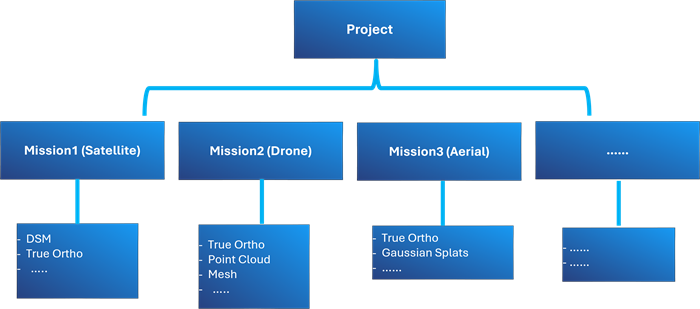

## Reality Mapping Workflow

Reality mapping workflow can be completed using the steps illustrated below:

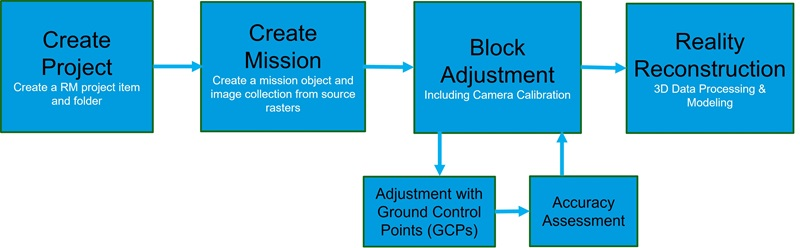

### Step 1: Create a Project

The first step is to create/initiate a reality mapping project using the [Project](https://developers.arcgis.com/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster.realitymapping.Project) class of the reality mapping module.

In [ ]:
project = realitymapping.Project("project_name")

Project creation involves creating a new portal folder and a reality mapping project item inside that folder. The project item contains the basic information (e.g. project name, group name, workspace name, etc.) that defines a reality mapping project. All related image services and products generated in subsequent steps will be stored in the project folder.

A project can also be initiated using an existing project's item ID. This is useful when continuing work on a previously created project:

In [ ]:
project = realitymapping.Project.from_item(gis.content.get("item_id"))

### Step 2: Create a Mission

After initiating a project, the next step is to create a mission using the [create_mission()](https://developers.arcgis.com/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster.realitymapping.Project.create_mission) method of the project object.  Mission creation involves creating an image collection for the source rasters.

The type of rasters to create an image collection for can be defined using the [ImageSource](https://developers.arcgis.com/python/latest/api-reference/arcgis.raster.toc.html#imagesource) class:

In [ ]:
uav_src = realitymapping.ImageSource("UAV/UAS")


The raster type can be any of supported aerial types such as `UAV/UAS` for drones, `Frame Table` for digital aerial, `Scanned Aerial Imagery` for scanned aerial photos or any of the supported satellite sensors such as `WorldView-1`, `GeoEye-1` etc. The current supported raster types is listed below:

['ASTER', 'Aerial', 'DMCII', 'DubaiSat-2', 'Frame Camera', 'GF-1 PMS', 'GF-1 WFV', 'GF-2 PMS', 'GRIB', 'GeoEye-1', 'HDF', 'IKONOS', 'Jilin-1', 'KOMPSAT-2', 'KOMPSAT-3', 'Landsat 1-5 MSS', 'Landsat 4-5 TM', 'Landsat 7 ETM+', 'Landsat 8', 'Landsat 9', 'PlanetScope', 'Pleiades NEO', 'Pleiades-1', 'QuickBird', 'RapidEye', 'SPOT 5', 'SPOT 6', 'SPOT 7', 'Sentinel-2', 'SkySat', 'Superview-1', 'UAV/UAS', 'WorldView-1', 'WorldView-2', 'WorldView-3', 'WorldView-4', 'ZY3-CRESDA', 'ZY3-SASMAC']

The properties of the rasters to be added can be defined using `raster_type` attribute of an ImageSource instance. Some properties are specific to the particular raster type while some are common to all raster types. To see the possible property for a raster type, use the attributes property of the [raster_type](https://developers.arcgis.com/python/latest/api-reference/arcgis.raster.toc.html#rastertype) instance.

`uav_src.raster_type.attributes`

The location of the input data to be added is defined using the `input_data` attribute of an ImageSource instance. This can be a local path or datastore (fileshare, cloudstore or rasterstore) registered with the server.

In [ ]:
uav_src.input_data = r"C:\SampleData\RM_Drone_Tutorial\Images"

After defining the type, properties and path of the source rasters, the mission and image collection can be created:

In [ ]:
mission = project.create_mission(image_sources = uav_src)

### Step 3: Perform Block Adjustment

After creating a mission and image collection, the next step is to perform block adjustment using the `compute_sensor_model()` method of the mission object.

In [ ]:
mission.compute_sensor_model()

 Block adjustment is a technique used in photogrammetry where an adjustment or transformation is computed for an area (a block) based on the photogrammetric relationship between overlapping images, a camera model, and elevation data. Block adjustment first calculate tie points, which are common points in overlapping images. The tie points are then used to calculate the orientation of each image, known as exterior orientation parameters as well as the interior orientation parameters such as focal length, principal point, pixel size, lens distortion. 

 Block adjustment generates the control points feature class, solution table, solution points feature class, and flight path feature class. These feature classes and tables will be saved in raster store and will not be created in the ArcGIS Enterprise as separated items.


Ground control points (GCP) can optionally be used to refine the adjustment result. After block adjustment, you can assess accuracy by generating adjustment report and reviewing the GCP residuals.

In [ ]:
mission.generate_report()

### Step 4: Generate Product

The final step after block adjustment is to generate products. The `reconstruct_surface()` method can generate one or multiple reality mapping products- DSM, DTM, true ortho, DSM Mesh, 3D meshes, and point clouds from adjusted imagery.

## Summary and Resources

The guide walks through the end‑to‑end reality mapping workflow, covering environment setup, project and mission management, image ingestion, block adjustment, and product generation. It explains how projects organize reality mapping work across multiple missions, how missions manage imagery from individual capture sessions, and how block adjustment establishes accurate image geometry using tie points and optional ground control points. Finally, it demonstrates how adjusted imagery is used to generate products such as true orthos, elevation models, point clouds, and 3D meshes, providing a foundation for accurate analysis, visualization, and decision‑making in enterprise geospatial workflows.

For more hands-on practice, see the tutorials listed below:

- <a href='create-trueortho-dsm-from-drone-imagery.ipynb'>Create true ortho and DSM product from drone imagery</a> 
- <a href='create-2D-digital-aerial-products.ipynb'>Create 2D digital aerial products from nadir imagery</a>
- <a href='create-3D-digital-aerial-products.ipynb'>Create 3D digital aerial products from oblique imagery</a>
- <a href='create-trueortho-dsm-from-satellite-imagery.ipynb'>Create true ortho and DSM product from satellite imagery</a>